<a href="https://colab.research.google.com/github/nandkishor-vasi/Coronal-Mass-Ejection-Detection/blob/main/FA2_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import cdflib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

cactus_text = """
# CME |          t0    | dt0| pa | da |  v  |  dv | minv| maxv| halo?
  0014|2025/10/04 04:48| 05 | 273| 100| 0222| 0052| 0108| 0330|
  0015|2025/10/04 12:00| 01 | 226| 006| 0338| 0699| 0297| 1736|
  0018|2025/10/04 17:00| 04 | 258| 090| 0209| 0046| 0124| 0335|
  0021|2025/10/04 21:12| 01 | 052| 018| 0744| 0134| 0589| 1008|
  0013|2025/10/03 00:04| 02 | 016| 090| 0426| 0734| 0125| 1953| II
  0034|2025/10/03 02:27| 02 | 036| 094| 0390| 0154| 0125| 0762|
  0002|2025/10/03 03:12| 02 | 036| 096| 0744| 0020| 0113| 0762| II
  0023|2025/10/03 12:29| 02 | 016| 022| 0426| 0734| 0125| 1953|
  0043|2025/10/03 21:12| 02 | 016| 022| 0426| 0734| 0125| 1953|
  0004|2025/10/03 23:36| 00 | 096| 014| 0203| 0020| 0191| 0249|
  0003|2025/10/03 21:24| 01 | 215| 020| 0126| 0004| 0120| 0131| II
  0019|2025/10/03 21:12| 02 | 016| 022| 0426| 0734| 0125| 1953|
  0012|2025/10/03 20:12| 02 | 036| 042| 0390| 0154| 0113| 0762|
  0022|2025/10/03 23:36| 00 | 096| 014| 0203| 0020| 0191| 0249| II
  0007|2025/10/03 21:24| 01 | 215| 020| 0126| 0004| 0120| 0131|
  0025|2025/10/03 21:12| 02 | 016| 022| 0426| 0734| 0125| 1953|
  0010|2025/10/03 20:12| 02 | 036| 042| 0390| 0154| 0113| 0762|
"""

lines = cactus_text.strip().split('\n')
cactus_events = []
for line in lines:
    if '|' in line and 'II' in line:
        parts = re.split(r'\s*\|\s*', line.strip())
        if len(parts) >= 10:
            t0_str = parts[1]
            v = float(parts[5])
            t0 = datetime.strptime(t0_str, '%Y/%m/%d %H:%M')
            cactus_events.append({'onset': t0, 'median_speed_km_s': v})

print("Extracted Halo CME Events:", cactus_events)

cdf_files = [
    "AL1_ASW91_L2_BLK_20251003_UNP_9999_999999_V02.cdf"
]

all_data = []

for cdf_file in cdf_files:
    try:
        cdf = cdflib.CDF(cdf_file)
        cdf_info = cdf.cdf_info()
        variables = cdf_info.zVariables

        data = {}
        for var in variables:
            values = cdf.varget(var)
            if "epoch_for_cdf_mod" in var.lower():
                try:
                    values = cdflib.cdfepoch.to_datetime(values)
                except Exception:
                    pass
            data[var] = values

        df = pd.DataFrame(data)
        all_data.append(df)
        print(f"Successfully loaded: {cdf_file}")
    except Exception as e:
        print(f"Error reading {cdf_file}: {e}")

if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    csv_file = "combined_cdf_output.csv"
    combined_df.to_csv(csv_file, index=False)
    print(f"Combined CDFs → CSV ({csv_file})")
else:
    print("No valid CDF files were loaded.")

Extracted Halo CME Events: [{'onset': datetime.datetime(2025, 10, 3, 0, 4), 'median_speed_km_s': 426.0}, {'onset': datetime.datetime(2025, 10, 3, 3, 12), 'median_speed_km_s': 744.0}, {'onset': datetime.datetime(2025, 10, 3, 21, 24), 'median_speed_km_s': 126.0}, {'onset': datetime.datetime(2025, 10, 3, 23, 36), 'median_speed_km_s': 203.0}]
Successfully loaded: AL1_ASW91_L2_BLK_20251003_UNP_9999_999999_V02.cdf
Combined CDFs → CSV (combined_cdf_output.csv)


Cleaned data shape: (4264, 10)


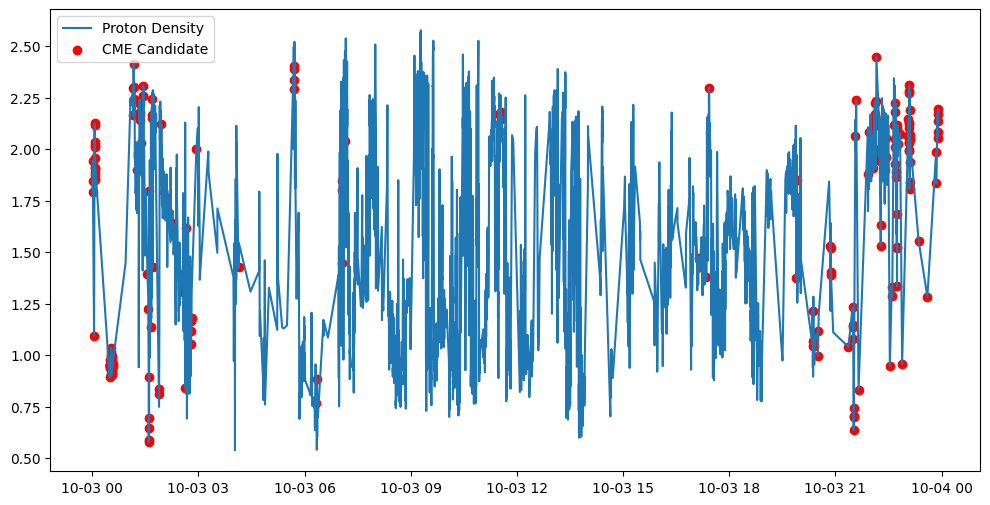

Columns in df_filtered:
- epoch_for_cdf_mod
- proton_density
- proton_bulk_speed
- proton_thermal
- alpha_density
- alpha_bulk_speed
- alpha_thermal
- spacecraft_xpos
- spacecraft_ypos
- spacecraft_zpos
- anomaly_score
- is_cme_candidate


In [ ]:

time_col = 'epoch_for_cdf_mod'
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[time_col] = pd.to_datetime(df[time_col])

drop_cols = ['numden_p_uncer','bulk_p_uncer','thermal_p_uncer',
             'numden_a_uncer','bulk_a_uncer','thermal_a_uncer',
             'proton_xvelocity','proton_yvelocity','proton_zvelocity']
numerical_cols = [col for col in numerical_cols if col not in drop_cols]

df_filtered = df[[time_col] + list(numerical_cols)].replace(-1e31, np.nan).dropna()
print("Cleaned data shape:", df_filtered.shape)

features = df_filtered.select_dtypes(include=['float64', 'int64']).columns

iso = IsolationForest(contamination=0.05, random_state=42)
df_filtered["anomaly_score"] = iso.fit_predict(df_filtered[features])
df_filtered["is_cme_candidate"] = df_filtered["anomaly_score"].apply(lambda x: 1 if x == -1 else 0)

if "proton_density" in df_filtered.columns:
    plt.figure(figsize=(12,6))
    plt.plot(df_filtered[time_col], df_filtered["proton_density"], label="Proton Density")
    plt.scatter(df_filtered[time_col][df_filtered["is_cme_candidate"]==1],
            df_filtered["proton_density"][df_filtered["is_cme_candidate"]==1],
            color="red", label="CME Candidate")
    plt.legend()
    plt.show()

print("Columns in df_filtered:")
for col in df_filtered.columns:
    print("-", col)


**Reasoning**:
Calculate Q1, Q3, IQR, and the lower and upper bounds for each numerical column in the filtered DataFrame to identify potential outliers.



CME #1 Arrival Window: 2025-10-03 01:02:41.126761+00:00 → 2025-10-04 01:02:41.126761+00:00 | matched 4209 rows
CME #2 Arrival Window: 2025-10-03 03:45:36.129032+00:00 → 2025-10-04 03:45:36.129032+00:00 | matched 3726 rows
CME #3 Arrival Window: 2025-10-04 00:42:24.761905+00:00 → 2025-10-05 00:42:24.761905+00:00 | matched 0 rows
CME #4 Arrival Window: 2025-10-04 01:39:09.162562+00:00 → 2025-10-05 01:39:09.162562+00:00 | matched 0 rows
Total CME windows (y_true=1): 4209
Total CME candidates: 214
CACTUS Validation Metrics:
  Precision: 0.75
  Recall:    0.04
  F1-score:  0.07
Detected velocity column: proton_bulk_speed
Rule-based severity counts: {'Severe': 4264}
Rule produced only one class — using quantile-based severity.
Final severity distribution:
 severity
Mild        1422
Moderate    1421
Severe      1421
Name: count, dtype: int64


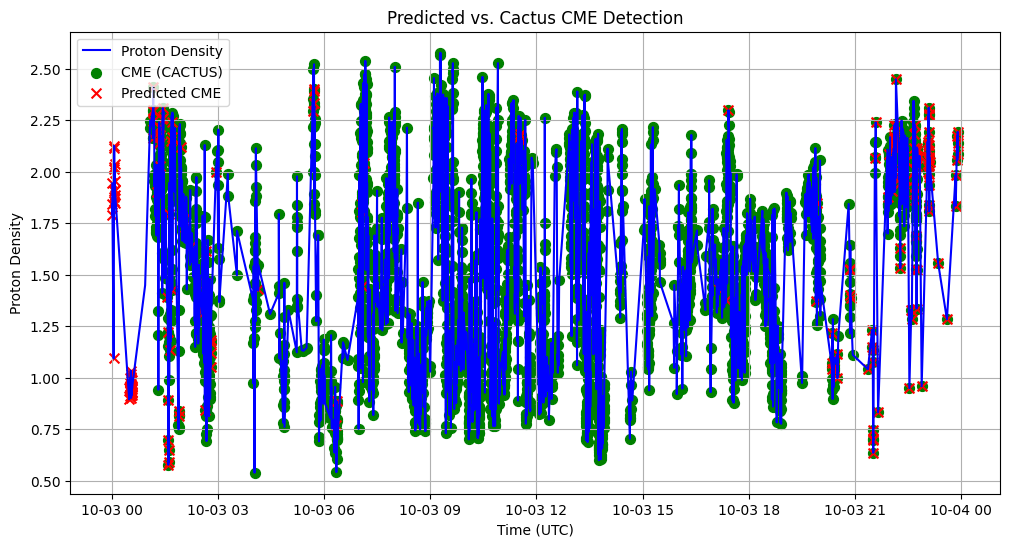

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

time_col = 'epoch_for_cdf_mod'
df_filtered[time_col] = pd.to_datetime(df_filtered[time_col], utc=True)
df_filtered['y_true'] = 0

for ev in cactus_events:
    ev['onset'] = pd.to_datetime(ev['onset'], utc=True)

AU_km = 1.5e6
for i, event in enumerate(cactus_events):
    if not event.get('median_speed_km_s'):
        print(f"Skipping event {i}: missing median_speed_km_s")
        continue

    travel_hours = (AU_km / float(event['median_speed_km_s'])) / 3600.0
    arrival_time = event['onset'] + timedelta(hours=travel_hours)
    end_time = arrival_time + timedelta(hours=24)

    mask = (df_filtered[time_col] >= arrival_time) & (df_filtered[time_col] < end_time)
    df_filtered.loc[mask, 'y_true'] = 1

    print(f"CME #{i+1} Arrival Window: {arrival_time} → {end_time} | matched {mask.sum()} rows")

n_true = int(df_filtered['y_true'].sum())
n_pred = int(df_filtered['is_cme_candidate'].sum())
print(f"Total CME windows (y_true=1): {n_true}")
print(f"Total CME candidates: {n_pred}")

if n_true == 0 and n_pred == 0:
    print("CACTUS Validation Metrics: No overlapping events ")
else:
    prec = precision_score(df_filtered['y_true'], df_filtered['is_cme_candidate'], zero_division=0)
    rec = recall_score(df_filtered['y_true'], df_filtered['is_cme_candidate'], zero_division=0)
    f1 = f1_score(df_filtered['y_true'], df_filtered['is_cme_candidate'], zero_division=0)
    print("CACTUS Validation Metrics:")
    print(f"  Precision: {prec:.2f}")
    print(f"  Recall:    {rec:.2f}")
    print(f"  F1-score:  {f1:.2f}")

def classify_severity(v):
    if pd.isna(v):
        return np.nan
    if v > 500:
        return 'Severe'
    elif v > 300:
        return 'Moderate'
    else:
        return 'Mild'

velocity_col = next((c for c in df_filtered.columns if 'velocity' in c.lower() or 'bulk' in c.lower()), None)
print(f"Detected velocity column: {velocity_col}")

if velocity_col:
    df_filtered['severity_rule'] = df_filtered[velocity_col].apply(classify_severity)
    counts = df_filtered['severity_rule'].value_counts(dropna=False)
    print("Rule-based severity counts:", counts.to_dict())

    if counts.dropna().nunique() < 2:
        print("Rule produced only one class — using quantile-based severity.")
        df_filtered['severity'] = pd.qcut(
            df_filtered[velocity_col].fillna(df_filtered[velocity_col].median()),
            q=3, labels=['Mild', 'Moderate', 'Severe']
        )
    else:
        df_filtered['severity'] = df_filtered['severity_rule']
else:
    print("No velocity column found — assigning all as 'Mild'.")
    df_filtered['severity'] = 'Mild'

print("Final severity distribution:\n", df_filtered['severity'].value_counts())

features = [col for col in numerical_cols if col in df_filtered.columns]
X = df_filtered[features].copy()
y = df_filtered['severity']

if y.nunique() < 2:
    print("Skipping severity classifier — only one severity class found.")
else:
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    X_proc = pipeline.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_proc, y, test_size=0.3, random_state=42, stratify=y
    )

    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(df_filtered['epoch_for_cdf_mod'], df_filtered['proton_density'], label="Proton Density", color='blue')

actual_mask = df_filtered['y_true'] == 1
plt.scatter(df_filtered.loc[actual_mask, 'epoch_for_cdf_mod'], df_filtered.loc[actual_mask, 'proton_density'],
            color='green', label='CME (CACTUS)', s=50, marker='o')

pred_mask = df_filtered['is_cme_candidate'] == 1
plt.scatter(df_filtered.loc[pred_mask, 'epoch_for_cdf_mod'], df_filtered.loc[pred_mask, 'proton_density'],
            color='red', label='Predicted CME', s=50, marker='x')

plt.xlabel("Time (UTC)")
plt.ylabel("Proton Density")
plt.title("Predicted vs. Cactus CME Detection")
plt.legend()
plt.grid(True)
plt.show()